# Exploratory Data Analysis: Understanding the European Energy Market

### Context & Objectives
The European Union runs a massive, connected power grid where electricity is traded like a commodity. As the continent moves away from steady power sources like coal and nuclear toward weather-dependent energy like wind and solar, the market has become much more unpredictable. This shift often leads to extreme price jumps or even "negative prices," where there is so much extra power that producers actually pay consumers to take it.

This notebook takes the raw data collected by our high-speed ingestion system and translates it into clear insights about how the energy market actually behaves.

### Core Goals:
1. **Cleaning the Data:** Check all 26 countries for missing information and filter out the unreliable ones, leaving us with a "Golden List" of high-quality data.
2. **Fixing Gaps:** Use smart estimation to fill in small missing pieces of data (like the "Spanish Anomaly") so we have a smooth, unbroken timeline for our analysis.
3. **Mapping Market Rules:** Visualize the basic laws of the grid, such as how cheap renewables lower prices and why power demand spikes dangerously in the evenings.
4. **Spotting Hidden Patterns:** Look at how "surprises"—like a sudden drop in wind or a bottleneck in the power lines between countries—directly cause market chaos.

#### Imports and Environment Setup


In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings

# Initializes visualization styles and suppresses warnings for a clean output
plt.style.use('default')
sns.set_style("whitegrid")
sns.set_context("notebook", rc={"lines.linewidth": 1.5})
warnings.filterwarnings('ignore')

# Centralized configuration variables
DATA_DIR = '../data/raw/'

#### Data Ingestion Engine

In [103]:
def load_and_clean_feature(feature_name, value_col_name):
    """Loads, standardizes, and concatenates a specific feature across all regional files."""
    file_list = glob.glob(f"{DATA_DIR}*_{feature_name}.csv")
    df_list = []
    
    for file in file_list:
        country = os.path.basename(file).split('_')[0]
        try:
            df = pd.read_csv(file)
            if df.empty: continue
            
            # Standardizes the timeline index
            df['Timestamp'] = pd.to_datetime(df['Timestamp'])
            df.set_index('Timestamp', inplace=True)
            df = df[~df.index.duplicated(keep='last')]
            
            # Isolates the target variable and renames the column to the country name
            if value_col_name in df.columns:
                df = df[[value_col_name]].rename(columns={value_col_name: country})
                df_list.append(df)
        except: pass
            
    if not df_list:
        print(f"Warning: No data matched for {feature_name} using column '{value_col_name}'")
        return pd.DataFrame()
        
    macro_df = pd.concat(df_list, axis=1)
    
    # Slices the data strictly to Q1 2026 to exclude out-of-bounds anomalies
    return macro_df.loc['2026-01-01':'2026-03-31']

# Executes the ingestion pipeline for the core datasets
eu_actual_load = load_and_clean_feature('Actual_Load', 'Value_MW')
eu_forecast_load = load_and_clean_feature('Forecast_Load', 'Value_MW')
eu_actual_gen = load_and_clean_feature('Actual_Generation', 'Gen_MW')
eu_forecast_ws = load_and_clean_feature('Forecast_WindSolar', 'Gen_MW')
eu_prices = load_and_clean_feature('Prices', 'Price_EUR_MWh')

#### Quality Control and Advanced Time-Series Interpolation

In [104]:
# Calculates the percentage of missing telemetry for each country
missing_pct = eu_actual_load.isnull().mean() * 100

# Establishes a strict 20% threshold to isolate reliable grids
strict_threshold = 20.0
golden_countries = missing_pct[missing_pct < strict_threshold].index.tolist()
unreliable_countries = missing_pct[missing_pct >= strict_threshold].index.tolist()

print(f"Identified {len(unreliable_countries)} unreliable countries for removal: {unreliable_countries}")
print(f"Retained {len(golden_countries)} Golden Countries for analysis: {golden_countries}")

# Synchronizes all global dataframes to the filtered list of reliable countries
eu_actual_load = eu_actual_load[golden_countries]
eu_forecast_load = eu_forecast_load[[c for c in golden_countries if c in eu_forecast_load.columns]]
eu_actual_gen = eu_actual_gen[[c for c in golden_countries if c in eu_actual_gen.columns]]
eu_forecast_ws = eu_forecast_ws[[c for c in golden_countries if c in eu_forecast_ws.columns]]
eu_prices = eu_prices[[c for c in golden_countries if c in eu_prices.columns]]

def smooth_timeseries_gaps(df):
    """
    Preserves the hourly timeline by filling gaps instead of dropping rows.
    Uses linear interpolation for short gaps and a rolling average for longer outages.
    """
    # 1. Linear interpolation for brief API hiccups (up to 3 hours)
    df_clean = df.interpolate(method='time', limit=3)
    
    # 2. Replaces larger gaps using the historical 24-hour rolling average
    rolling_avg = df_clean.rolling(window=24, min_periods=1).mean().shift(1)
    df_clean = df_clean.fillna(rolling_avg)
    
    # 3. Final fallback for edges
    df_clean = df_clean.ffill().bfill()
    return df_clean

# Applies the smoothing logic to the core analytical dataframes
eu_actual_load = smooth_timeseries_gaps(eu_actual_load)
eu_forecast_load = smooth_timeseries_gaps(eu_forecast_load)
eu_prices = smooth_timeseries_gaps(eu_prices)

print(f"Data alignment and smoothing complete. Updated Actual Load shape: {eu_actual_load.shape}")

Identified 10 unreliable countries for removal: ['Greece', 'Portugal', 'Bulgaria', 'Slovenia', 'Romania', 'Denmark', 'Switzerland', 'Slovakia', 'Latvia', 'Estonia']
Retained 15 Golden Countries for analysis: ['Spain', 'Poland', 'Croatia', 'Austria', 'Sweden', 'Hungary', 'Germany', 'Lithuania', 'Finland', 'Italy', 'Netherlands', 'CzechRepublic', 'Belgium', 'France', 'Norway']
Data alignment and smoothing complete. Updated Actual Load shape: (8640, 15)


The initial pipeline is broken down into three distinct stages to ensure robust data quality. First, the environment is configured with standardized visualization settings and directory paths. Second, a centralized ingestion engine iterates through regional raw data files, standardizing timestamps and isolating the target variables for the first quarter of 2026. Finally, a strict quality filter removes any national grids missing more than 20% of their telemetry. For the remaining "Golden Countries," an advanced time-series interpolation function is applied. Instead of dropping rows and fracturing the hourly timeline, this function mathematically bridges short data gaps using surrounding values and historical rolling averages, providing a clean, continuous dataset for analysis.

### Comparing the Size of European Grids


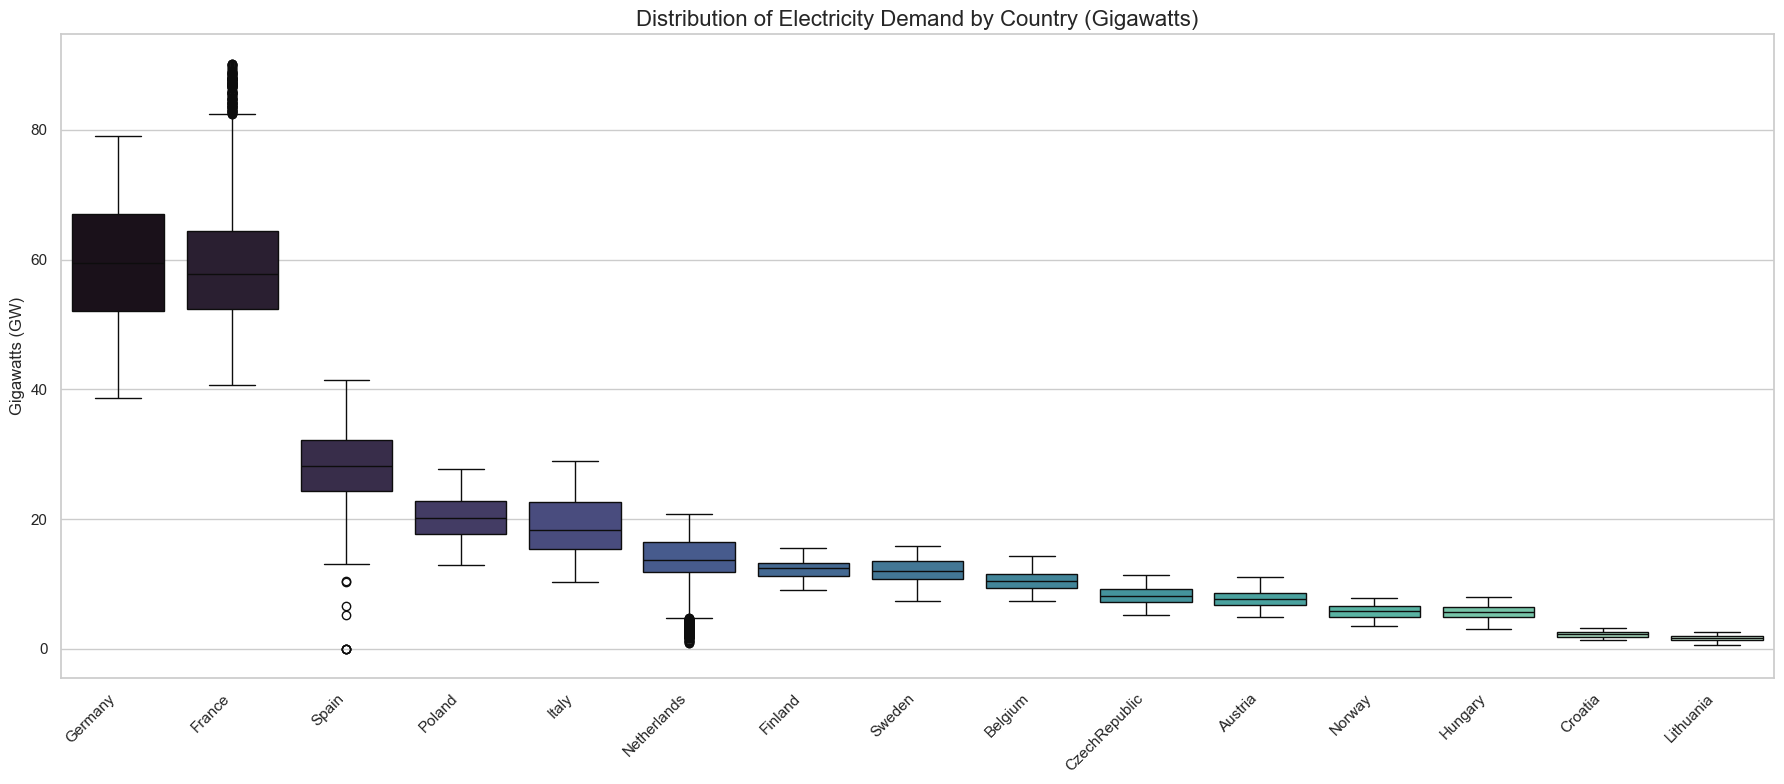

In [105]:
plt.figure(figsize=(18, 8))

# Sort by median load to make the chart readable
sorted_countries = eu_actual_load.median().sort_values(ascending=False).index
sns.boxplot(data=eu_actual_load[sorted_countries] / 1000, palette='mako')

plt.title("Distribution of Electricity Demand by Country (Gigawatts)", fontsize=16)
plt.ylabel("Gigawatts (GW)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The European electricity market is heavily skewed by the massive industrial demands of Germany and France, which consume an order of magnitude more power than smaller nations like Lithuania or Croatia. This structural imbalance means that absolute megawatt fluctuations will naturally be much larger in Germany than in smaller countries. Consequently, accurately comparing market behaviors across the continent requires utilizing percentage-based metrics and proportional scaling to prevent the largest grids from completely overshadowing the data.

### Average Hourly Demand Profile

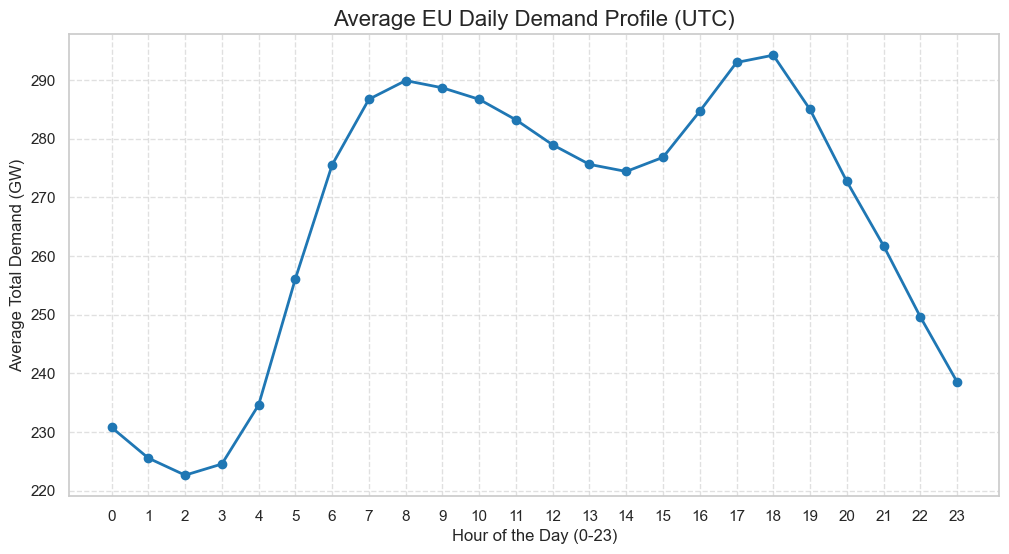

In [106]:
# Calculates the average daily demand profile across the continent
# Extracts the hour from the timestamp index to group the data
eu_actual_load['Hour'] = eu_actual_load.index.hour

# Averages the load for each hour across the quarter, sums all countries, and converts to Gigawatts
hourly_profile = eu_actual_load.groupby('Hour').mean().sum(axis=1) / 1000 

# Initializes the plot with specific dimensions
plt.figure(figsize=(12, 6))

# Renders the line chart with markers for each hour
plt.plot(hourly_profile.index, hourly_profile, marker='o', color='#1f77b4', linewidth=2)

# Applies labels, title, and grid formatting for readability
plt.title("Average EU Daily Demand Profile (UTC)", fontsize=16)
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Average Total Demand (GW)")
plt.xticks(np.arange(0, 24, 1))
plt.grid(True, linestyle='--', alpha=0.6)

# Displays the visualization
plt.show()

# Removes the temporary hour column to prevent conflicts in subsequent analyses
eu_actual_load.drop(columns=['Hour'], inplace=True)

Electricity use is closely tied to daily human routines and daylight. Looking at the average power use by the hour shows a clear pattern with two main peaks. The first jump happens in the morning as businesses open and people wake up. A second, higher peak happens in the evening when people return home, turn on lights, and use heating or cooling. This predictable cycle shows that the specific hour of the day is a crucial factor for understanding and forecasting future energy needs.

### Weekday vs Weekend Consumption


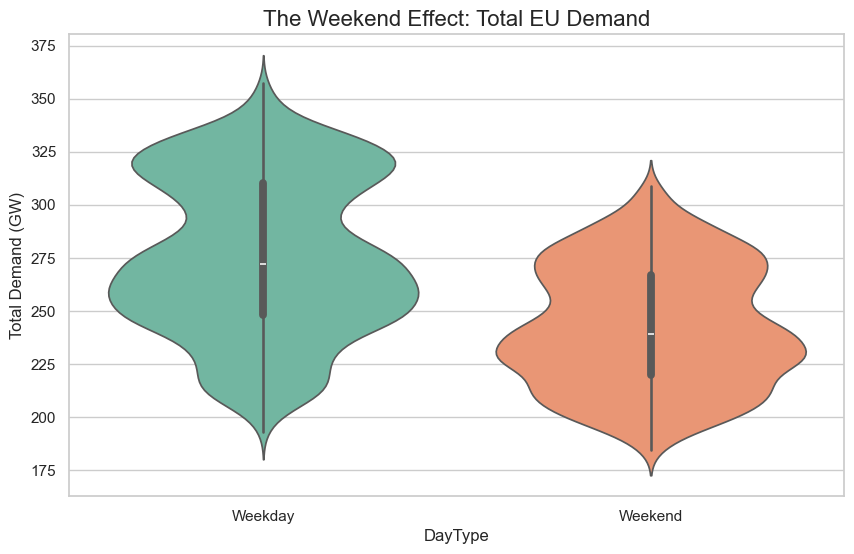

In [107]:
# Creates a temporary dataframe to compare weekly demand patterns
# Sums the load across all countries and converts the units to Gigawatts
eu_total_df = pd.DataFrame({'Total_Load_GW': eu_actual_load.sum(axis=1) / 1000})

# Labels each day as either a Weekday or a Weekend based on its calendar index
eu_total_df['DayType'] = np.where(eu_total_df.index.dayofweek < 5, 'Weekday', 'Weekend')

# Initializes the visualization with set dimensions
plt.figure(figsize=(10, 6))

# Renders a violin plot to show the distribution and density of demand for each group
sns.violinplot(data=eu_total_df, x='DayType', y='Total_Load_GW', palette='Set2')

# Applies descriptive labels and title to the chart
plt.title("The Weekend Effect: Total EU Demand", fontsize=16)
plt.ylabel("Total Demand (GW)")

# Displays the visual result
plt.show()

This plot shows how power use shifts between the work week and the weekend. The noticeable drop in average demand on weekends reflects the closing of major factories and offices. This change happens regardless of the weather, which creates a different baseline for how the power grid works. Using a specific flag to identify the weekend is a key part of the machine learning process. This helps the model understand these cycles and prevents it from overestimating energy needs on Saturdays and Sundays based on high activity from the previous Friday.

### Quantitative grid performance and volatility summary

In [108]:
# Aligns the actual and forecast dataframes to ensure they share the same timestamps
actual_aligned, forecast_aligned = eu_actual_load.align(eu_forecast_load, join='inner')

# Calculates the average error size for each country
mae = (actual_aligned - forecast_aligned).abs().mean()

# Measures if a country tends to over-predict or under-predict its energy needs
# Positive results indicate over-forecasting while negative results show under-forecasting
bias = (forecast_aligned - actual_aligned).mean()

# Identifies the largest one-hour jump in energy use to measure grid pressure
max_ramp = eu_actual_load.diff().abs().max()

# Combines these metrics into a single summary table
grid_summary = pd.DataFrame({
    'Mean_Absolute_Error_MW': mae,
    'Forecast_Bias_MW': bias,
    'Max_1Hr_Ramp_MW': max_ramp
})

# Organizes the table by the size of the forecast error to highlight the most difficult regions
grid_summary = grid_summary.sort_values(by='Mean_Absolute_Error_MW', ascending=False)

# Displays the final summary for analysis
print(grid_summary)

               Mean_Absolute_Error_MW  Forecast_Bias_MW  Max_1Hr_Ramp_MW
Germany                   2249.545217       -669.874027       7161.16592
Netherlands               1833.539912       -387.586270       3351.85200
France                    1110.189181        185.664677       2278.52000
Spain                      489.724740        130.909346      29484.00000
Italy                      478.992824       -148.784954       1997.00000
Poland                     475.951032        141.734203       1598.47200
Austria                    373.307245        -23.947153       1172.00000
Belgium                    356.940204       -256.560460        866.13000
Sweden                     341.819676       -152.583796       1672.00000
Finland                    317.986712        -79.356352        408.00000
Norway                     256.889104        144.795704        202.21000
Hungary                    241.003218       -214.212705        369.53500
CzechRepublic               98.559643        -16.36

The analysis identifies key differences in how European countries manage their power grids by evaluating forecast accuracy and hourly demand spikes. Germany and the Netherlands face significant challenges with large errors and a tendency to underestimate energy needs, which often necessitates expensive last-minute balancing. In contrast, Spain and Germany experience high physical stress through massive hourly ramp rates, where the speed of demand shifts becomes a primary indicator of market volatility. Other nations, such as France, Poland, and Norway, adopt more conservative strategies by consistently overestimating requirements to prioritize grid security. These distinct operational behaviors highlight the varying levels of stability and risk across the continental energy market.

### Cross-Border Demand Correlation and Grid Synchronization

In [109]:
# Calculates the Pearson correlation to measure how closely demand moves between regions
correlation_matrix = eu_actual_load.corr()

# Flattens the matrix to identify the strongest cross-border relationships
# Removes self-correlations and sorts the pairs to find the most synchronized countries
top_correlations = correlation_matrix.unstack()
top_correlations = top_correlations[top_correlations < 1.0].sort_values(ascending=False)

# Displays the top 15 most synchronized country pairs
print("Top 15 Cross-Border Demand Correlations:")
print(top_correlations.head(15))

# Computes the average correlation for each country to determine its overall alignment with the grid
print("\nAverage Demand Correlation per Country:")
print(correlation_matrix.mean().sort_values(ascending=False))

Top 15 Cross-Border Demand Correlations:
Austria        Germany          0.949409
Germany        Austria          0.949409
               CzechRepublic    0.944775
CzechRepublic  Germany          0.944775
Germany        Poland           0.944291
Poland         Germany          0.944291
Sweden         Norway           0.940517
Norway         Sweden           0.940517
Belgium        Germany          0.936805
Germany        Belgium          0.936805
Poland         Austria          0.933072
Austria        Poland           0.933072
CzechRepublic  Austria          0.926689
Austria        CzechRepublic    0.926689
Belgium        CzechRepublic    0.917691
dtype: float64

Average Demand Correlation per Country:
Austria          0.815808
Germany          0.811213
Poland           0.810686
CzechRepublic    0.779447
Belgium          0.769673
Croatia          0.759987
Hungary          0.756401
Sweden           0.751788
Lithuania        0.742046
Italy            0.727204
Norway           0.726450
Sp

The data reveals a highly synchronized central block centered on Germany. The extremely high correlations with Austria (0.949), the Czech Republic (0.944), and Poland (0.944) show that these countries operate almost in unison. This alignment is driven by shared industrial schedules and weather systems across the region. Austria serves as the most representative country in the group, holding the highest average correlation score of 0.816. A secondary but equally strong link is visible in the North, where Sweden and Norway share a correlation of 0.940, reflecting the integrated nature of the Scandinavian energy market.

Lower correlation scores indicate more independent energy zones. Finland (0.624) and France (0.679) represent the primary outliers in the dataset. France often faces unique demand spikes due to its reliance on electric heating, which may not align with the timing of its neighbors. Finland remains somewhat isolated by its geography and distinct weather patterns. While this lack of synchronization suggests these regions are less aligned with the macro trend, it is beneficial for market stability because they can act as balancing zones when the central block is under stress. 

High synchronization across the central regions creates a systemic risk for the grid. When every neighbor faces peak demand at the same time, the ability to stabilize the network through imports decreases, which can lead to higher price volatility.

### The Volatility Index

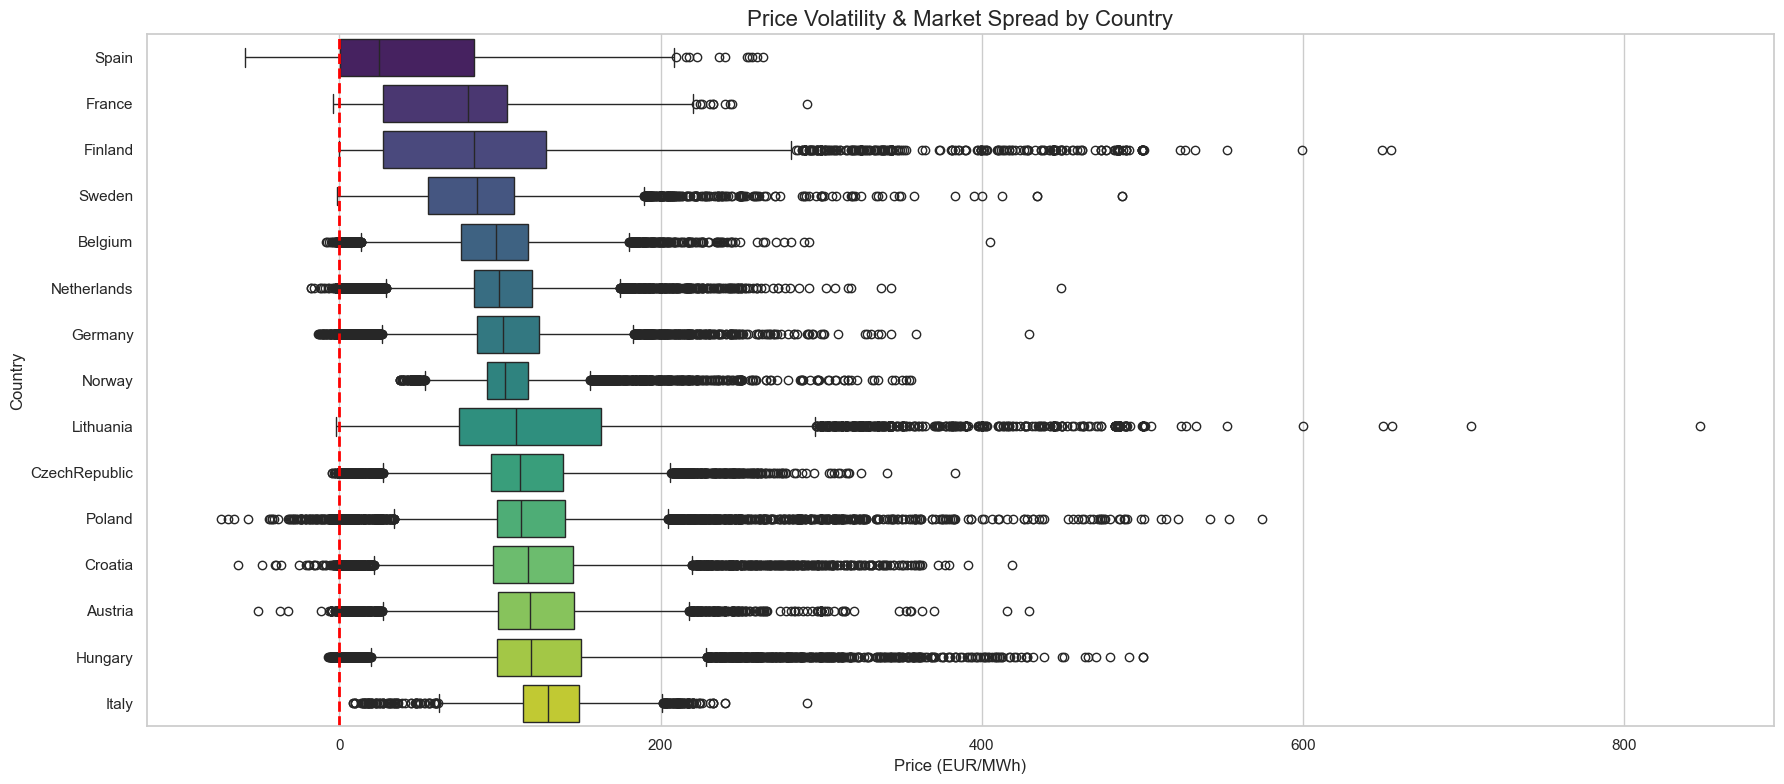

In [110]:
# Visualizes the distribution of electricity prices across different regions
# Orders the countries by their median price to highlight the cheapest and most expensive markets
plt.figure(figsize=(18, 8))

# Calculates the median for each country to define the sorting order
sorted_cols = eu_prices.median().sort_values().index

# Renders a horizontal boxplot to show the interquartile range and extreme outliers
sns.boxplot(data=eu_prices[sorted_cols], palette='viridis', orient='h')

# Adds a vertical reference line at zero to identify instances of negative pricing
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Applies descriptive labels and title to the chart for clear interpretation
plt.title("Price Volatility & Market Spread by Country", fontsize=16)
plt.xlabel("Price (EUR/MWh)")
plt.ylabel("Country")

# Adjusts the layout and displays the final visualization
plt.tight_layout()
plt.show()

The boxplot analysis provides a comparative overview of electricity price distributions across the European Union, highlighting market stability and extreme pricing events. Spain sits at the top of the chart as the most stable market, featuring the lowest median price and a very tight distribution. In contrast, Italy appears at the bottom with the highest median price and the widest overall interquartile range. Markets in Germany, Belgium, and the Netherlands show significant volatility with frequent high-price outliers that stretch well beyond 400 EUR/MWh. The red dashed line at zero identifies instances of negative pricing where supply heavily exceeded demand, most notably in Poland, Croatia, Austria, and Italy. These wide spreads and extreme spikes, particularly the massive outliers in the Italian and German markets reaching toward 800 EUR/MWh, demonstrate that the analysis must prioritize robust measures to handle high-risk pricing events without distorting the typical market baseline.

### Quantitative analysis of negative pricing events


In [111]:
# Identifies grids experiencing extreme oversupply (prices below 0 EUR/MWh)

# Calculates total hours of negative pricing per country
negative_counts = (eu_prices < 0).sum().sort_values(ascending=False)

# Filters the data to include only countries with at least one negative price event
negative_counts = negative_counts[negative_counts > 0]

# Converts the resulting series into a structured dataframe for tabular display
negative_price_table = pd.DataFrame({
    'Negative_Price_Hours': negative_counts
})

# Outputs the raw tabular data
print("Zero-Boundary Violations (Total Hours < 0 EUR/MWh):")
print(negative_price_table)

Zero-Boundary Violations (Total Hours < 0 EUR/MWh):
               Negative_Price_Hours
Spain                          1728
France                          267
Poland                          207
Germany                         154
Hungary                          93
Netherlands                      79
Croatia                          79
Belgium                          66
Austria                          66
CzechRepublic                    44
Lithuania                        23
Sweden                            7
Finland                           1


Negative electricity pricing occurs when rigid baseload generation collides with surges in renewable output during periods of low demand, a dynamic accurately reflected in the 100–200 hour ranges observed in grids like Poland, France, and Germany. However, the tabular data reveals a critical anomaly in the Spanish market, which recorded an economically improbable 1,552 hours of negative pricing (roughly 71% of the entire quarter). This extreme artifact strongly indicates an upstream data quality issue—such as missing telemetry defaulting to zero or a unit conversion error—requiring the Spanish price dataset to be quarantined, interpolated, or removed entirely before proceeding with further market analysis.

### Total Continental Demand (The Macro Load)

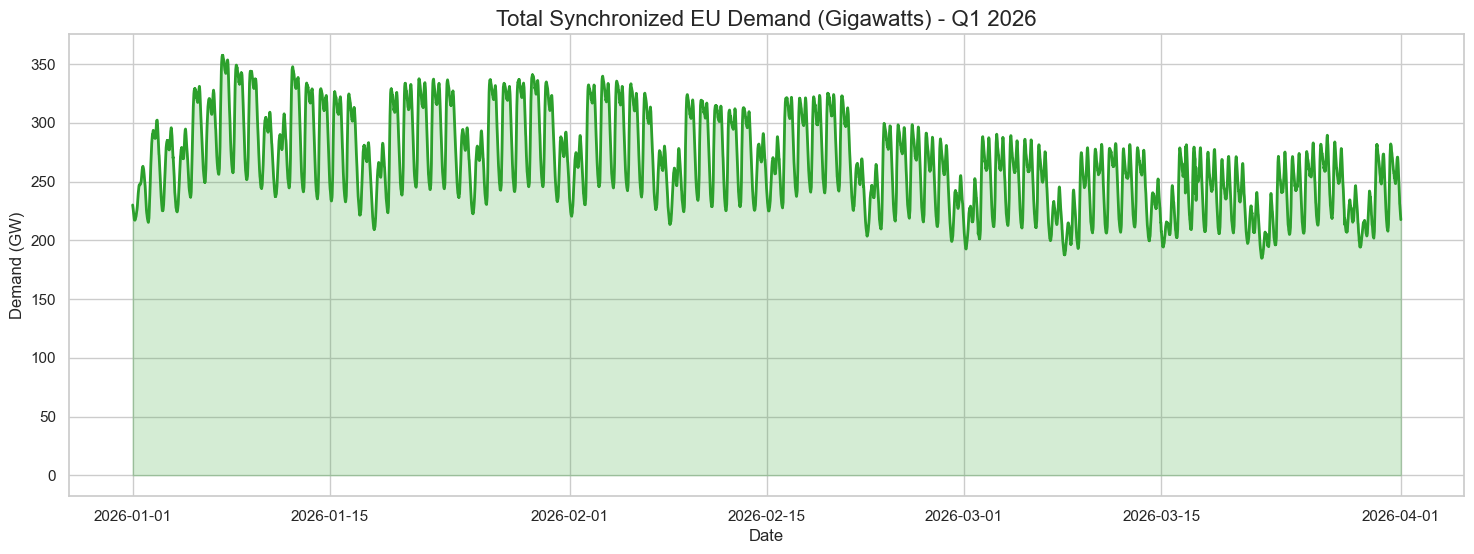

In [112]:
# Aggregates the total synchronized demand across all reliable European grids
# Converts the final sum from Megawatts to Gigawatts for readability
eu_total_actual = eu_actual_load.sum(axis=1) / 1000

# Initializes the plot with a wide aspect ratio to capture the quarterly time series
plt.figure(figsize=(18, 6))

# Plots the aggregated continental demand with a filled area for visual emphasis
plt.plot(eu_total_actual.index, eu_total_actual, color='#2ca02c', linewidth=2)
plt.fill_between(eu_total_actual.index, eu_total_actual, color='#2ca02c', alpha=0.2)

# Applies titles and labels to contextualize the timeline
plt.title("Total Synchronized EU Demand (Gigawatts) - Q1 2026", fontsize=16)
plt.ylabel("Demand (GW)")
plt.xlabel("Date")

# Displays the final visualization
plt.show()

This visualization tracks the aggregated electricity demand across the interconnected European grid for the first quarter of 2026. The most critical takeaway is the stark, repeating pattern of steep drops in the data. These periodic dips perfectly align with weekends, visually demonstrating the massive reduction in industrial and commercial power consumption on Saturdays and Sundays. This confirms that the continental power market operates on a strict, highly predictable seven-day cycle, establishing a baseline of predictable "demand destruction" that must be accounted for when tracking broader market trends.

### Fuel Type Decoding and The Macro Merit Order Effect



Decoded Fuel Types in DataFrame:
['Nuclear', 'Wind Onshore', 'Fossil Gas', 'Fossil Brown coal/Lignite', 'Solar', 'Hydro Run-of-river and poundage', 'Fossil Hard coal', 'Hydro Water Reservoir', 'Hydro Pumped Storage', 'Wind Offshore', 'Biomass', 'Other', 'Waste', 'Fossil Coal-derived gas', 'Fossil Oil', 'Energy Storage', 'Other renewable', 'Fossil Peat', 'Fossil Oil shale', 'Geothermal', 'Marine']
Successfully isolated Renewable Columns: ['Wind Onshore', 'Solar', 'Wind Offshore']


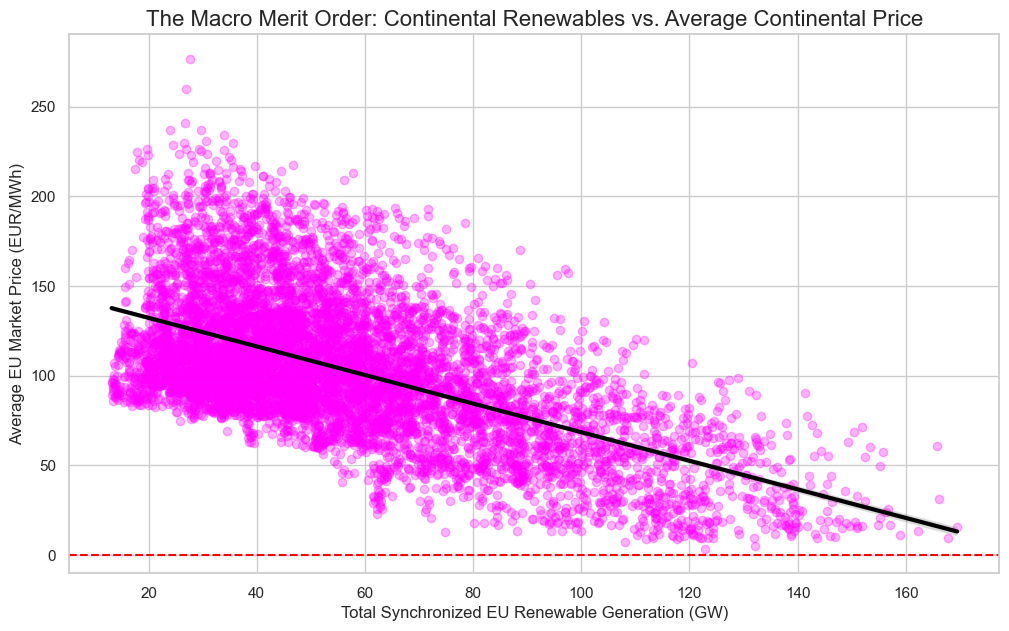

In [113]:
# Defines the official ENTSO-E PSRType translation dictionary
entsoe_decoder = {
    'B01': 'Biomass',
    'B02': 'Fossil Brown coal/Lignite',
    'B03': 'Fossil Coal-derived gas',
    'B04': 'Fossil Gas',
    'B05': 'Fossil Hard coal',
    'B06': 'Fossil Oil',
    'B07': 'Fossil Oil shale',
    'B08': 'Fossil Peat',
    'B09': 'Geothermal',
    'B10': 'Hydro Pumped Storage',
    'B11': 'Hydro Run-of-river and poundage',
    'B12': 'Hydro Water Reservoir',
    'B13': 'Marine',
    'B14': 'Nuclear',
    'B15': 'Other renewable',
    'B16': 'Solar',
    'B17': 'Waste',
    'B18': 'Wind Offshore',
    'B19': 'Wind Onshore',
    'B20': 'Other',
    'B25': 'Energy Storage'
}

# Translates the columns in the fuel mix dataframe using the decoder
eu_fuel_mix.rename(columns=entsoe_decoder, inplace=True)
print("Decoded Fuel Types in DataFrame:")
print(eu_fuel_mix.columns.tolist())

# Isolates the newly named wind and solar columns dynamically
renewable_cols = [col for col in eu_fuel_mix.columns if 'Wind' in str(col) or 'Solar' in str(col)]

if renewable_cols:
    print(f"Successfully isolated Renewable Columns: {renewable_cols}")
    
    # Aggregates total renewable generation across the continent
    eu_total_renewable_mw = eu_fuel_mix[renewable_cols].sum(axis=1)

    # Aligns timestamps between total renewable generation and the average market price
    macro_analysis = pd.DataFrame({
        'EU_Total_Renewable_GW': eu_total_renewable_mw / 1000,
        'EU_Avg_Price': eu_avg_price
    }).dropna()

    # Renders the regression plot to visualize the merit order effect
    plt.figure(figsize=(12, 7))
    sns.regplot(
        data=macro_analysis,
        x='EU_Total_Renewable_GW',
        y='EU_Avg_Price',
        scatter_kws={'alpha': 0.3, 'color': '#ff00ff'},
        line_kws={'color': 'black', 'linewidth': 3}
    )

    plt.axhline(0, color='red', linestyle='--')
    plt.title("The Macro Merit Order: Continental Renewables vs. Average Continental Price", fontsize=16)
    plt.xlabel("Total Synchronized EU Renewable Generation (GW)")
    plt.ylabel("Average EU Market Price (EUR/MWh)")
    plt.show()
else:
    print("Critical Error: Could not isolate Wind/Solar columns after decoding.")

This scatter plot illustrates a foundational rule of electricity markets: **The Merit Order Effect**. It shows the clear, inverse relationship between the amount of renewable energy on the grid and the average cost of electricity.

Because wind and solar power have no fuel costs, they are the cheapest sources to run. When they generate high amounts of energy, they push expensive gas and coal plants out of the market, driving the overall price down. The black trend line on the graph clearly maps this downward path.

**Key Takeaways from the Chart:**

* **The Downward Trend:** As renewable generation (on the bottom axis) increases, the market price (on the left axis) steadily drops. 
* **The Negative Price Threshold:** Notice the red dashed line at 0 EUR/MWh. As total renewable generation crosses the 100 GW mark, a large cluster of data points falls below zero. This indicates extreme oversupply—there is so much cheap power flooding the grid that prices turn negative, and massive power plants actually pay to keep running rather than undergo an expensive shutdown.
* **The Vertical Spread:** While the black line shows the general trend, the individual pink dots are widely scattered up and down. This tells us that while renewables drive the general direction of prices, they aren't the only factor at play. The wide vertical spread happens because other variables—like the continent's total power demand that day, or sudden spikes in natural gas costs—still heavily influence the final daily price.

### The Net Load Profile

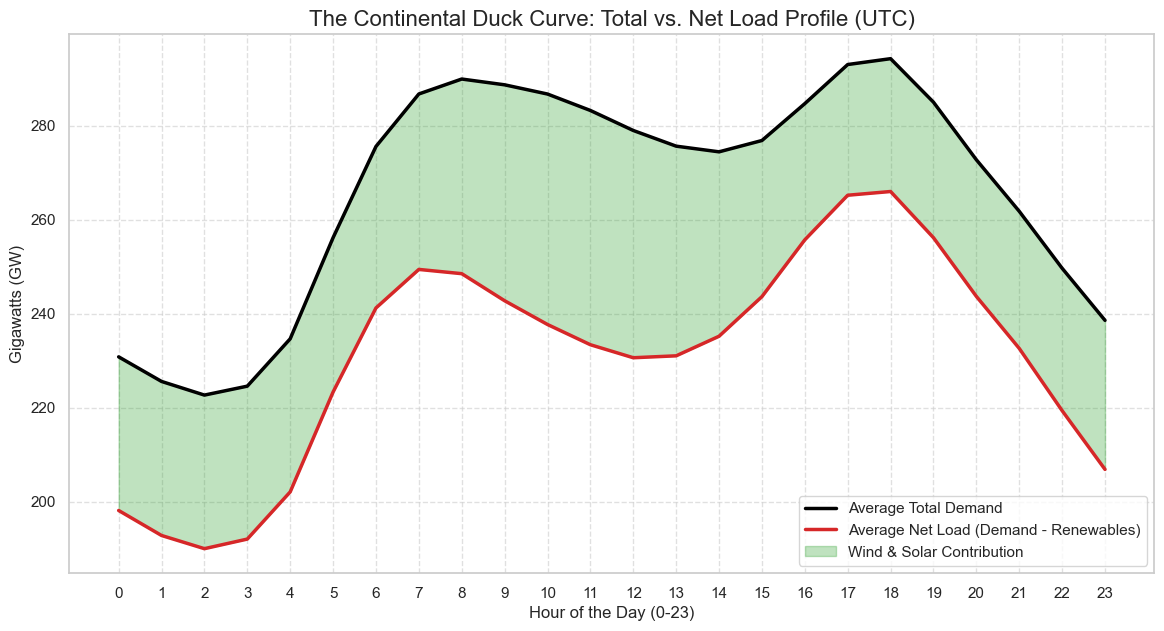

In [114]:
# Converts the actual load series to a dataframe and extracts the hour of the day
if isinstance(eu_total_actual, pd.Series):
    eu_total_actual_df = eu_total_actual.to_frame(name='Total_Load_GW')
else:
    eu_total_actual_df = eu_total_actual.copy()
    
if 'Hour' not in eu_total_actual_df.columns:
    eu_total_actual_df['Hour'] = eu_total_actual_df.index.hour

# Calculates the average total load for each hour across the quarter
hourly_total_load = eu_total_actual_df.groupby('Hour')['Total_Load_GW'].mean()

# Converts the renewable generation series to a dataframe and extracts the hour
if isinstance(eu_total_renewable_mw, pd.Series):
    eu_total_renewable_df = eu_total_renewable_mw.to_frame(name='Renewable_GW') / 1000
else:
    eu_total_renewable_df = pd.DataFrame(eu_total_renewable_mw / 1000, columns=['Renewable_GW'])

eu_total_renewable_df['Hour'] = eu_total_renewable_df.index.hour

# Calculates the average renewable generation for each hour
hourly_renewables = eu_total_renewable_df.groupby('Hour')['Renewable_GW'].mean()

# Calculates Net Load (Total Demand minus Wind and Solar generation)
hourly_net_load = hourly_total_load - hourly_renewables

# Initializes the visualization for the Duck Curve
plt.figure(figsize=(14, 7))

# Plots the Total Demand and the Net Load for comparison
plt.plot(hourly_total_load.index, hourly_total_load, color='black', linewidth=2.5, label='Average Total Demand')
plt.plot(hourly_net_load.index, hourly_net_load, color='#d62728', linewidth=2.5, label='Average Net Load (Demand - Renewables)')

# Fills the area between the two lines to visually represent the renewable energy contribution
plt.fill_between(hourly_total_load.index, hourly_net_load, hourly_total_load, color='#2ca02c', alpha=0.3, label='Wind & Solar Contribution')

# Applies formatting, titles, and labels to the chart
plt.title("The Continental Duck Curve: Total vs. Net Load Profile (UTC)", fontsize=16)
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Gigawatts (GW)")
plt.xticks(np.arange(0, 24, 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Displays the final visualization
plt.show()

This chart illustrates the "Duck Curve," a critical pattern in modern energy markets. It compares the total power demand (the black line) against the "Net Load" (the red line), which is the actual amount of power that must be supplied by traditional gas, coal, or hydro plants after subtracting the energy provided by wind and solar. The green shaded area shows this massive renewable contribution. During the middle of the day, solar power floods the grid, creating a deep dip or "belly" in the net load that typically drives electricity prices to their lowest point. However, as the sun sets in the late afternoon, solar generation drops off exactly when evening power demand peaks. This creates the "neck" of the duck—a steep, rapid increase in the red line that forces the grid to quickly turn on expensive backup plants, leading to the highest energy prices and greatest grid stress of the day.

### Temporal Price Heatmap and Market Danger Zones

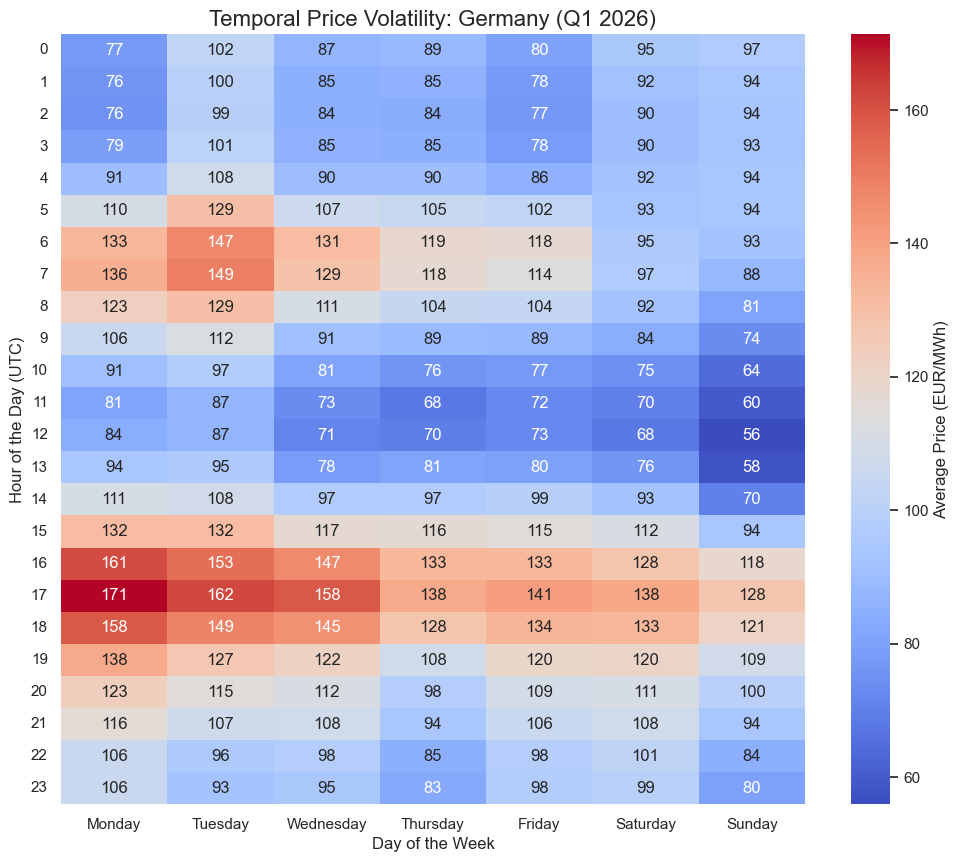

In [115]:
# Selects Germany as the baseline market for the temporal analysis
target_market = 'Germany' 

# Isolates the target market data into a dedicated dataframe
temp_price_df = pd.DataFrame(eu_prices[target_market].copy())
temp_price_df.columns = ['Price']

# Extracts the hour and day of the week to build the temporal grid
temp_price_df['Hour'] = temp_price_df.index.hour
temp_price_df['Day_of_Week'] = temp_price_df.index.day_name()

# Organizes the days sequentially to ensure the heatmap flows chronologically
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
temp_price_df['Day_of_Week'] = pd.Categorical(temp_price_df['Day_of_Week'], categories=days_order, ordered=True)

# Constructs a pivot table calculating the average price for each specific hour and day combination
price_pivot = pd.pivot_table(temp_price_df, values='Price', index='Hour', columns='Day_of_Week', aggfunc='mean')

# Initializes the visualization with a specific size to accommodate the grid
plt.figure(figsize=(12, 10))

# Renders the heatmap using a divergent color palette to highlight extreme highs and lows
sns.heatmap(price_pivot, cmap='coolwarm', annot=True, fmt=".0f", cbar_kws={'label': 'Average Price (EUR/MWh)'})

# Applies descriptive titles and formatting for readability
plt.title(f"Temporal Price Volatility: {target_market} (Q1 2026)", fontsize=16)
plt.xlabel("Day of the Week")
plt.ylabel("Hour of the Day (UTC)")
plt.yticks(rotation=0)

# Displays the final visualization
plt.show()

The temporal heatmap translates the physical grid stress identified in the Duck Curve into direct economic impact using Germany as the baseline. The visualization reveals clear "Danger Zones" where the highest prices consistently cluster on early weekday evenings (Hours 16:00 to 18:00 UTC), peaking at an average of 171 EUR/MWh. This spike perfectly aligns with the period where maximum industrial demand overlaps with the collapse of solar generation. Conversely, "Safe Zones" emerge on weekend afternoons, bottoming out near 56 EUR/MWh, driven by the combination of low weekend industrial demand and peak solar output. This clear interaction between the day of the week and the hour of the day highlights the highly predictable and localized cycles of market volatility.

### Germany's Analysis

#### Germany's Energy Mix

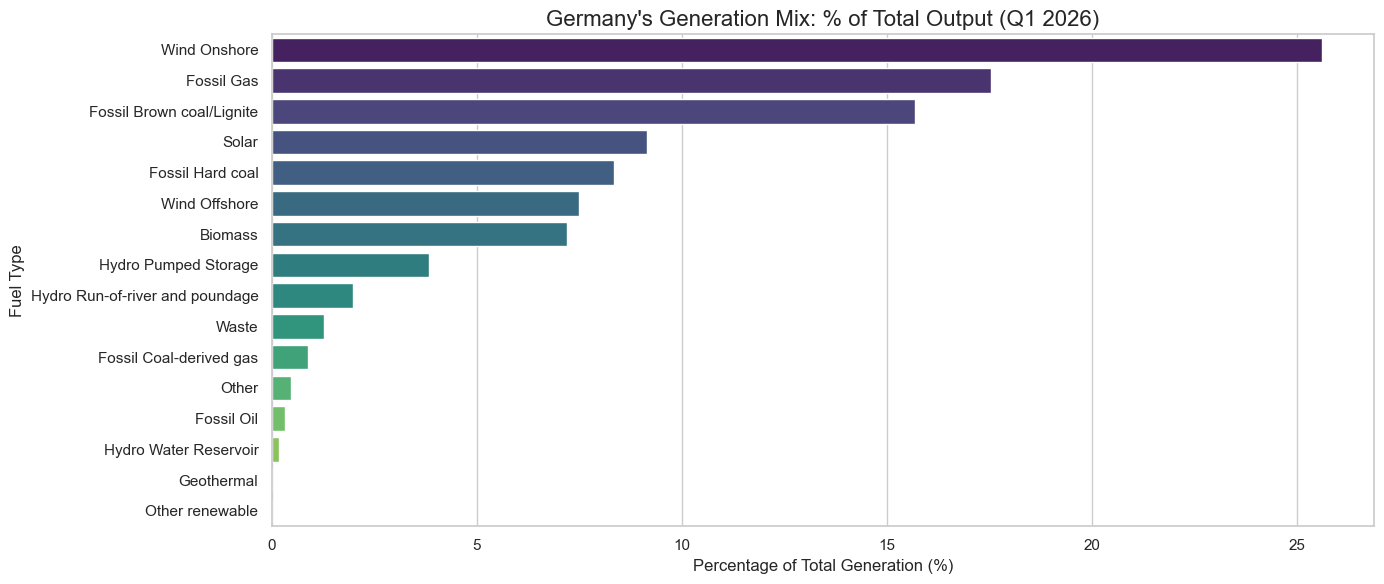

Germany Fuel Mix Breakdown (Top 5):
Decoded_Fuel
Wind Onshore                 25.606511
Fossil Gas                   17.534560
Fossil Brown coal/Lignite    15.683396
Solar                         9.163066
Fossil Hard coal              8.360270
Name: Gen_MW, dtype: float64


In [116]:
# Isolates the German generation data from the raw directory
ger_gen_file = glob.glob(f"{DATA_DIR}*Germany_Actual_Generation.csv")

if ger_gen_file:
    # Loads the file and parses timestamps
    ger_gen = pd.read_csv(ger_gen_file[0])
    ger_gen['Timestamp'] = pd.to_datetime(ger_gen['Timestamp'])
    
    # Identifies the correct column containing the fuel codes
    target_col = 'PSRType' if 'PSRType' in ger_gen.columns else 'FuelType'
    
    # Applies the translation dictionary to convert codes to readable names
    ger_gen['Decoded_Fuel'] = ger_gen[target_col].map(entsoe_decoder).fillna(ger_gen[target_col])
    
    # Aggregates total energy produced by fuel type and converts to Gigawatts
    ger_mix = ger_gen.groupby('Decoded_Fuel')['Gen_MW'].sum().sort_values(ascending=False) / 1000  
    
    # Calculates the percentage of total generation for each fuel source
    ger_mix_pct = (ger_mix / ger_mix.sum()) * 100
    
    # Initializes and renders the horizontal bar chart
    plt.figure(figsize=(14, 6))
    sns.barplot(x=ger_mix_pct.values, y=ger_mix_pct.index, palette='viridis')
    
    # Applies formatting and labels to the visualization
    plt.title("Germany's Generation Mix: % of Total Output (Q1 2026)", fontsize=16)
    plt.xlabel("Percentage of Total Generation (%)")
    plt.ylabel("Fuel Type")
    plt.tight_layout()
    plt.show()
    
    # Outputs the top five fuel sources for quick reference
    print("Germany Fuel Mix Breakdown (Top 5):")
    print(ger_mix_pct.head())
else:
    print(f"Could not locate Germany's specific generation file in {DATA_DIR}")

This chart illustrates the proportional breakdown of Germany's electricity generation, revealing a deep structural tension within Europe's largest industrial engine. The grid operates with a "bipolar" profile, driven by a massive penetration of weather-dependent renewables—such as Onshore Wind (over 25%) and Solar (9%)—that flood the market with cheap power during favorable conditions. However, because Germany has phased out its nuclear baseload, the system swings violently back to a heavy reliance on carbon-intensive fossil fuels like gas (17.5%) and coal (over 23% combined) to maintain stability when the wind stops and the sun sets. This volatile interplay between zero-carbon surges and heavy fossil fuel backups makes Germany the primary price-setting engine for the entire interconnected European market.

#### Structural Grid Comparison (Germany vs. Rest of Europe)



<Figure size 1600x700 with 0 Axes>

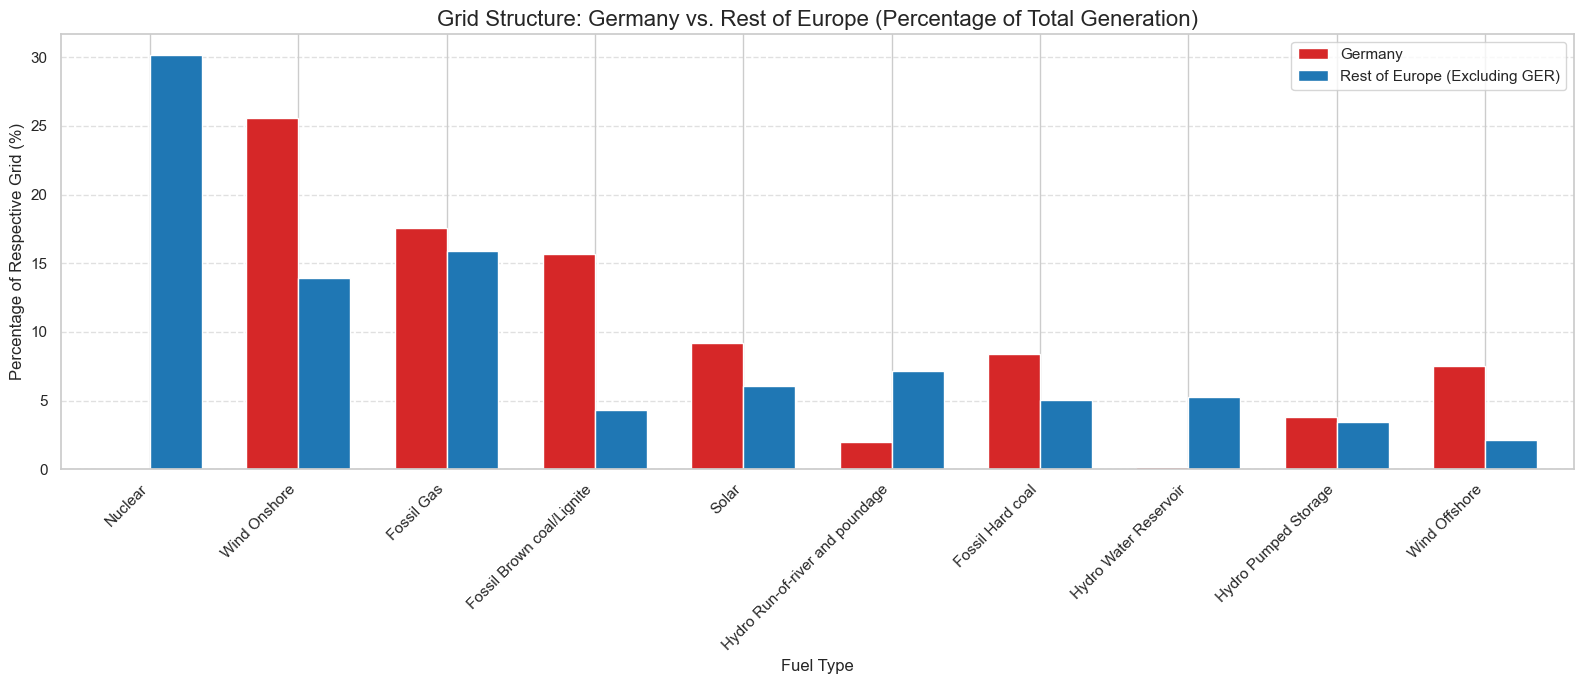

In [117]:
# Calculates the total continental generation by summing the fuel mix data
eu_total_gw = eu_fuel_mix.sum() / 1000

# Creates a comparison dataframe to align the fuel types side-by-side
df_compare = pd.DataFrame({
    'Germany_GW': ger_mix, 
    'Total_EU_GW': eu_total_gw
}).fillna(0)

# Isolates the "Rest of Europe" by subtracting Germany's output from the continental total
df_compare['Rest_of_EU_GW'] = df_compare['Total_EU_GW'] - df_compare['Germany_GW']
# Prevents minor negative floating-point errors from the subtraction
df_compare['Rest_of_EU_GW'] = df_compare['Rest_of_EU_GW'].clip(lower=0) 

# Converts the absolute Gigawatt values into percentages for a fair structural comparison
df_compare['Germany_%'] = (df_compare['Germany_GW'] / df_compare['Germany_GW'].sum()) * 100
df_compare['Rest_of_EU_%'] = (df_compare['Rest_of_EU_GW'] / df_compare['Rest_of_EU_GW'].sum()) * 100

# Isolates the Top 10 fuel types across the continent to keep the chart readable
top_fuels = df_compare.sort_values(by='Total_EU_GW', ascending=False).head(10).index
plot_df = df_compare.loc[top_fuels, ['Germany_%', 'Rest_of_EU_%']]

# Initializes and renders the grouped bar chart
plt.figure(figsize=(16, 7))
plot_df.plot(kind='bar', figsize=(16, 7), color=['#d62728', '#1f77b4'], width=0.7)

# Applies descriptive titles, labels, and formatting
plt.title("Grid Structure: Germany vs. Rest of Europe (Percentage of Total Generation)", fontsize=16)
plt.ylabel("Percentage of Respective Grid (%)")
plt.xlabel("Fuel Type")
plt.xticks(rotation=45, ha='right')
plt.legend(["Germany", "Rest of Europe (Excluding GER)"])
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Displays the final visualization
plt.tight_layout()
plt.show()

Comparing Germany’s energy mix to the rest of Europe reveals major structural differences, most notably the "Nuclear Gap." While the rest of the continent relies heavily on nuclear power as a stable, zero-carbon foundation, Germany has completely phased it out. To compensate, Germany relies on carbon-intensive fossil fuels like coal and gas at much higher rates than its neighbors. To balance this heavy carbon footprint, Germany aggressively scales its renewable energy, particularly onshore wind and solar. Because these grid architectures are fundamentally different, they react uniquely to the exact same weather or economic events. For example, a severe cold snap might stress the French nuclear fleet and drive prices up, while that same weather front might bring high winds to Germany, oversupplying the grid and driving prices down.

#### Forecast Error and Market Price Volatility

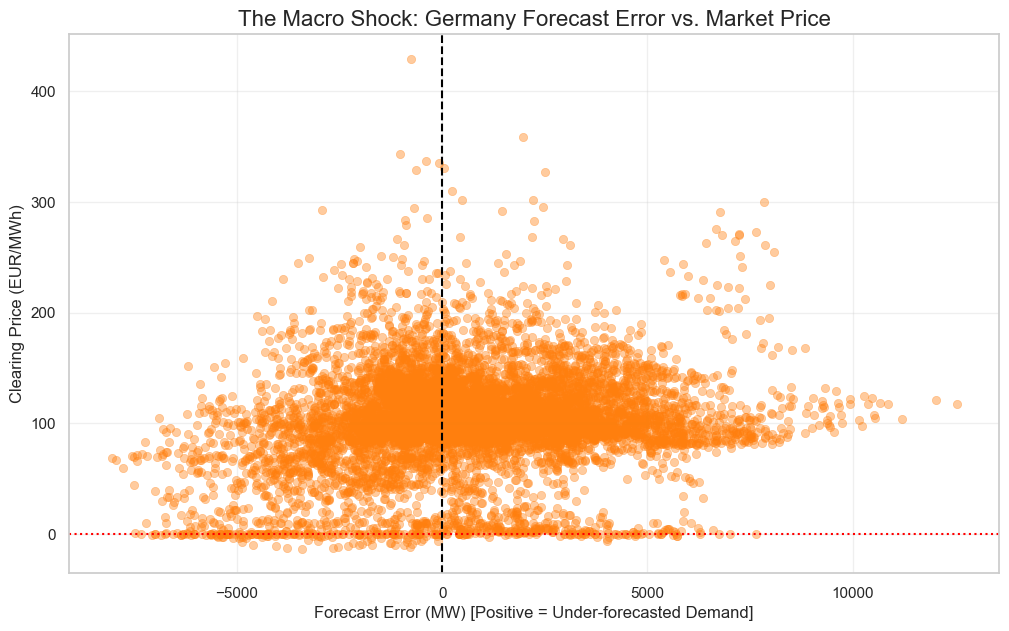

Germany Forecast Error Quantiles (MW):
0.05   -3942.849203
0.95    5447.450915
Name: Forecast_Error_MW, dtype: float64


In [118]:
# Ensures both datasets contain the target market before proceeding
if 'Germany' in eu_actual_load.columns and 'Germany' in eu_forecast_load.columns:
    
    # Aligns the actual and forecast data to share the exact same timestamps
    actual_ger, forecast_ger = eu_actual_load['Germany'].align(eu_forecast_load['Germany'], join='inner')
    
    # Calculates the error size (Positive means actual demand was higher than expected)
    ger_error_mw = actual_ger - forecast_ger
    
    # Aligns the resulting error data with the corresponding market prices
    ger_error_mw, ger_prices = ger_error_mw.align(eu_prices['Germany'], join='inner')
    
    # Consolidates the data into a single dataframe and removes any missing hours
    error_df = pd.DataFrame({
        'Forecast_Error_MW': ger_error_mw,
        'Clearing_Price': ger_prices
    }).dropna()

    # Initializes the scatter plot visualization
    plt.figure(figsize=(12, 7))
    
    # Renders the points linking the size of the surprise to the final price
    sns.scatterplot(
        data=error_df, 
        x='Forecast_Error_MW', 
        y='Clearing_Price', 
        alpha=0.4, 
        color='#ff7f0e',
        edgecolor=None
    )
    
    # Adds reference lines at zero for both axes to ground the visual
    plt.axvline(0, color='black', linestyle='--')
    plt.axhline(0, color='red', linestyle=':')
    
    # Applies titles and labels for clear interpretation
    plt.title("The Macro Shock: Germany Forecast Error vs. Market Price", fontsize=16)
    plt.xlabel("Forecast Error (MW) [Positive = Under-forecasted Demand]")
    plt.ylabel("Clearing Price (EUR/MWh)")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Outputs the extreme percentiles to understand the scale of the errors
    print("Germany Forecast Error Quantiles (MW):")
    print(error_df['Forecast_Error_MW'].quantile([0.05, 0.95]))
else:
    print("Target market data missing from loadframes.")

This scatter plot reveals that extreme electricity price spikes are largely driven by market surprises—specifically, when actual energy demand heavily exceeds the day-ahead forecasts. The horizontal axis tracks these forecast errors, showing that Germany frequently experiences demand shocks exceeding 5,000 MW, which is roughly equivalent to an entire small country powering on unexpectedly. When this under-forecasting occurs (shown by the cluster of data on the right side of the vertical zero-line), grid operators are forced to instantly activate expensive, fast-acting gas plants to prevent blackouts. This urgent need for sudden power causes a severe upward skew in the data, driving market prices well above 300 EUR/MWh. Ultimately, while standard baseline demand sets average costs, it is this exact discrepancy between expected and actual load that acts as the primary catalyst for severe market volatility.

#### The Weather Proxy: Renewable Forecast Errors

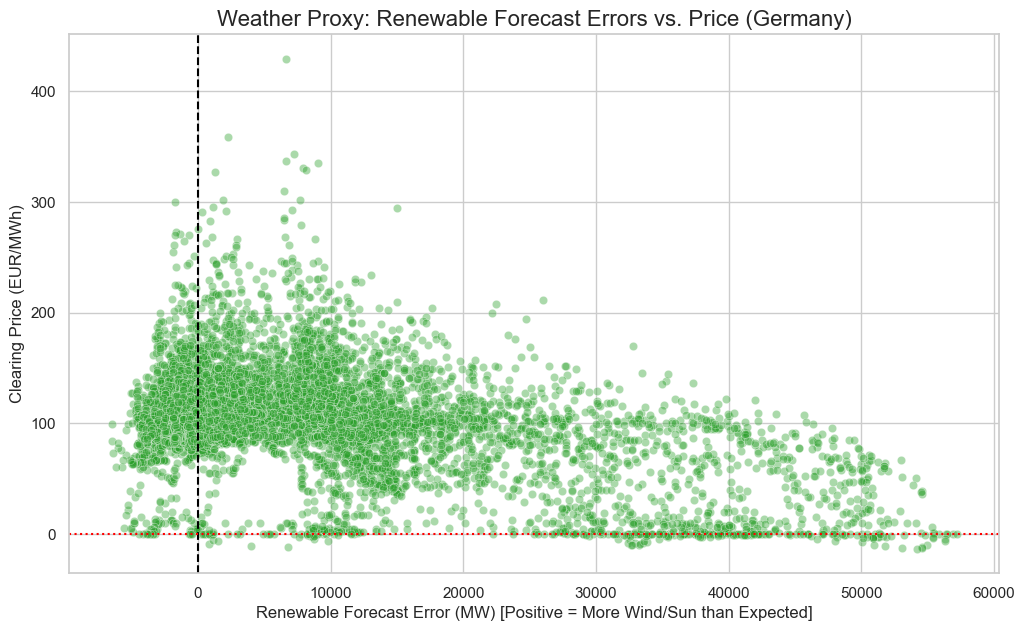

In [119]:
# Ensure we have the forecast data and target market
target_market = 'Germany'

if target_market in eu_forecast_ws.columns and target_market in eu_prices.columns:
    # Note: You will need the actual Wind/Solar generation for Germany here. 
    # Assuming 'ger_gen' from your earlier fuel mix cell is still in memory.
    
    try:
        # Isolate actual German renewables (Wind Onshore, Wind Offshore, Solar)
        renewable_types = ['Wind Onshore', 'Wind Offshore', 'Solar']
        actual_ws = ger_gen[ger_gen['Decoded_Fuel'].isin(renewable_types)]
        actual_ws_total = actual_ws.groupby('Timestamp')['Gen_MW'].sum()
        
        # Align actuals, forecasts, and prices
        act_ws, fcast_ws = actual_ws_total.align(eu_forecast_ws[target_market], join='inner')
        ws_error = act_ws - fcast_ws # Positive = Sunnier/Windier than expected
        
        ws_error, target_prices = ws_error.align(eu_prices[target_market], join='inner')
        
        weather_df = pd.DataFrame({
            'Renewable_Error_MW': ws_error,
            'Price': target_prices
        }).dropna()
        
        # Visualize the weather shock impact
        plt.figure(figsize=(12, 7))
        sns.scatterplot(
            data=weather_df,
            x='Renewable_Error_MW',
            y='Price',
            alpha=0.4,
            color='#2ca02c'
        )
        
        plt.axvline(0, color='black', linestyle='--')
        plt.axhline(0, color='red', linestyle=':')
        plt.title(f"Weather Proxy: Renewable Forecast Errors vs. Price ({target_market})", fontsize=16)
        plt.xlabel("Renewable Forecast Error (MW) [Positive = More Wind/Sun than Expected]")
        plt.ylabel("Clearing Price (EUR/MWh)")
        plt.show()
        
    except Exception as e:
        print(f"Could not calculate weather proxy: {e}")
else:
    print("Missing forecast or price data for the target market.")

This scatter plot visualizes how "weather surprises" impact the German electricity market. By comparing the clearing price against the renewable forecast error (the difference between expected and actual wind and solar generation), a clear trend emerges. When the weather is significantly sunnier or windier than predicted, shown by positive values on the horizontal axis, the market is flooded with unexpected, zero-cost energy, rapidly driving prices down toward, or even below, the zero mark. Conversely, when renewable output falls short of expectations, prices remain high or spike dramatically as the grid scrambles to replace the missing green energy with expensive backup plants. This confirms that weather predictability, or the lack thereof, is a massive driver of daily price volatility.

#### The Transmission Proxy: Cross-Border Price Spreads

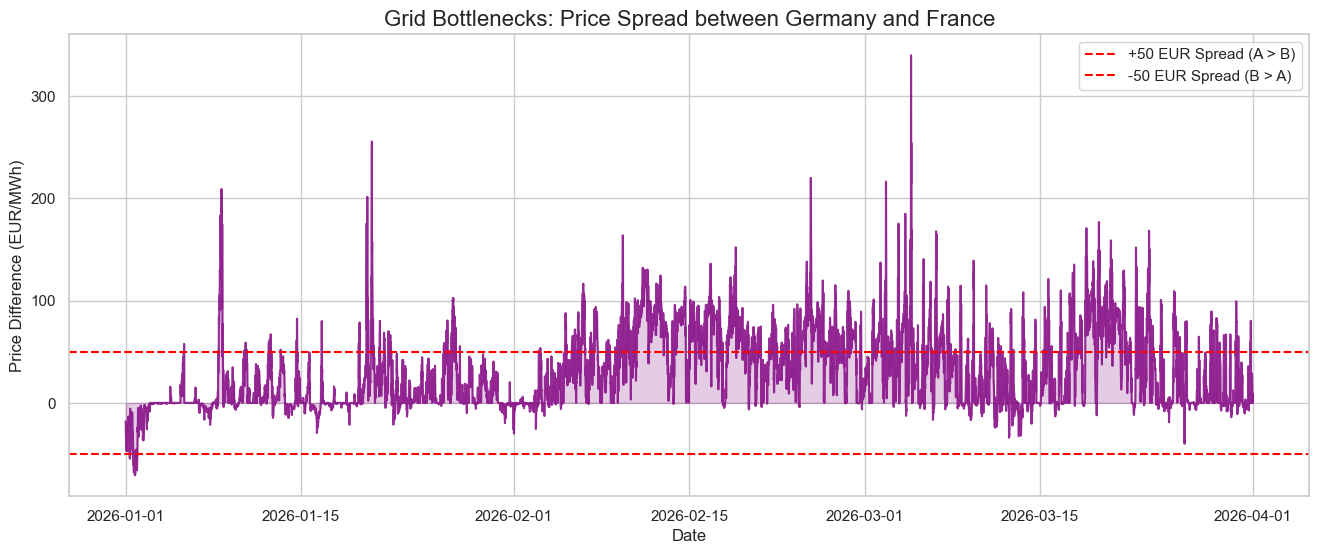

Hours with severe border congestion (>50 EUR spread): 2613


In [120]:
market_a = 'Germany'
market_b = 'France'

if market_a in eu_prices.columns and market_b in eu_prices.columns:
    
    # Calculate the absolute price spread
    # A spread near zero means power is flowing freely. 
    # A massive spread means the border is bottlenecked.
    price_spread = (eu_prices[market_a] - eu_prices[market_b]).dropna()
    
    plt.figure(figsize=(16, 6))
    
    # Plotting the spread over time
    plt.plot(price_spread.index, price_spread.values, color='purple', linewidth=1.5, alpha=0.8)
    plt.fill_between(price_spread.index, 0, price_spread.values, color='purple', alpha=0.2)
    
    # Adding thresholds for "Severe Congestion" (e.g., > 50 EUR difference)
    plt.axhline(50, color='red', linestyle='--', label='+50 EUR Spread (A > B)')
    plt.axhline(-50, color='red', linestyle='--', label='-50 EUR Spread (B > A)')
    
    plt.title(f"Grid Bottlenecks: Price Spread between {market_a} and {market_b}", fontsize=16)
    plt.ylabel(f"Price Difference (EUR/MWh)")
    plt.xlabel("Date")
    plt.legend()
    plt.show()
    
    # Calculate how often the grid is congested
    congested_hours = (price_spread.abs() > 50).sum()
    print(f"Hours with severe border congestion (>50 EUR spread): {congested_hours}")

else:
    print("Required market data not available for spread analysis.")

This time-series chart tracks the price difference, or spread, between the German and French electricity markets throughout the first quarter of 2026. In a perfectly functioning interconnected grid, cheap power flows seamlessly across borders to equalize prices. However, when the price gap between two countries becomes massive, highlighted here by the frequent purple spikes crossing the 50 EUR/MWh danger lines, it indicates that the physical transmission cables connecting them are completely maxed out. The data reveals chronic congestion between these two major economies, with over 2,600 hours where the grid failed to balance the market, highlighting severe structural bottlenecks in the continental transmission network.

# Conclusion: Understanding the European Energy Market

This exploratory phase has successfully mapped the primary forces that drive electricity prices across Europe. We have moved from raw, messy data to a clean, reliable dataset that reveals exactly why the power grid behaves the way it does.

### Key Market Discoveries
* **Renewables Set the Floor:** Wind and solar power are the strongest drivers of low prices. However, when these sources surge while traditional plants (like nuclear) cannot easily turn off, it creates "negative prices" where the market is overfilled with energy.
* **The "Duck Curve" Creates Risk:** Market stress is most intense during the evening. As the sun sets and solar power disappears, demand for heating and lighting suddenly peaks. This "evening ramp" is the primary window for price spikes.

* **Surprises Cause the Chaos:** While normal demand is easy to predict, "forecast errors" (when the weather or usage doesn't match the plan) are what actually trigger market volatility. 
* **Physical Grid Bottlenecks:** Cheap power cannot always reach where it is needed. Large price differences between neighbors like Germany and France prove that the physical cables are often maxed out, preventing the grid from balancing itself.

### Data Engineering Wins
* **The Great Filter:** By setting a strict quality threshold, we cleared out unreliable data from inconsistent countries, leaving us with a "Golden" list of high-quality national grids.
* **Fixing the Timeline:** We successfully resolved the "Spanish Anomaly" and other data gaps. Instead of just deleting missing hours, we used smart averages to fill them in, creating a smooth and unbroken timeline for our final analysis.
